# Case Study 1: Building a Mean-Variance Portfolio Pipeline

STAT 4170 — [Your Name]

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

RNG_SEED = 1
np.random.seed(RNG_SEED)

TICKERS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLB", "XLRE", "XLK", "XLU"]
MARKET = "SPY"
ALL_TICKERS = TICKERS + [MARKET]

## Section 1 - Data Pipeline

In [13]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RETURNS_CACHE_PATH = DATA_DIR / "sector_etf_returns.csv"
HISTORY_START = "2018-01-01"  # before all 12 tickers existed; XLC (2018) and XLRE (2015) trim the front


def _most_recent_expected_trading_day() -> pd.Timestamp:
    """Most recent trading day whose closing price should already be available.

    Approximates the NYSE calendar with a Mon-Fri rule and a 4:00pm US/Eastern
    close (no holiday calendar). On a market holiday this triggers one harmless
    extra refresh that just reconfirms the prior close -- it never serves stale
    data silently.
    """
    now_et = datetime.now(ZoneInfo("America/New_York"))
    day = pd.Timestamp(now_et.date())
    if now_et.hour < 16:
        day -= pd.Timedelta(days=1)
    while day.weekday() >= 5:  # roll weekends back to Friday
        day -= pd.Timedelta(days=1)
    return day.normalize()


def get_sector_returns(tickers=ALL_TICKERS, start=HISTORY_START, cache_path=RETURNS_CACHE_PATH, force_refresh=False):
    """Load daily simple returns for `tickers` since `start`, using a disk cache.

    On the first call (or whenever the cache is missing or stale), downloads
    adjusted daily closes via yfinance, converts to simple returns
    r_t = P_t / P_{t-1} - 1, and writes the returns (not prices) to
    `cache_path`. Later calls read the CSV directly and only hit the network
    again once the cached data no longer reaches the most recent expected
    trading day.
    """
    expected_latest = _most_recent_expected_trading_day()

    if cache_path.exists() and not force_refresh:
        cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        if cached.index.max() >= expected_latest:
            return cached

    prices = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"]
    prices = prices[tickers].sort_index()
    returns = prices.pct_change().dropna(how="any")
    returns.to_csv(cache_path)
    return returns


returns = get_sector_returns()
print(returns.shape)
returns.head(10)

(2059, 12)


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004741,0.000979,0.004415,-0.002560,0.002121,0.000683,-0.003248,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001957,-0.018516,-0.002933,-0.005762,-0.012554,-0.010635,0.005967,-0.007684,0.003385,-0.006269
2018-06-22,0.004376,-0.001704,0.008201,0.019951,-0.004779,0.004494,0.003455,0.014563,0.008742,-0.003238,0.006944,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009184,-0.012670,-0.015550,-0.002476,-0.020763,0.016552,-0.013613
2018-06-26,0.001658,0.007162,-0.004240,0.012629,-0.003360,-0.003089,0.003766,0.003819,0.005275,0.004039,0.001163,0.002214
2018-06-27,-0.008722,-0.012947,-0.002129,0.013410,-0.012364,-0.008464,-0.008060,-0.003113,-0.002778,-0.013648,0.004840,-0.008284
2018-06-28,0.009980,0.007851,0.000000,-0.001323,0.008725,0.001322,0.001401,0.003816,0.009904,0.012235,-0.000385,0.005718
2018-06-29,-0.001210,0.001742,-0.000581,0.006227,0.000000,0.002041,0.002098,0.003456,0.002452,-0.000431,0.001542,0.001440
2018-07-02,0.006259,0.001372,-0.005822,-0.014748,0.004889,0.003116,0.002234,-0.005338,-0.005808,0.008924,0.007121,0.002138


**Return convention.** We use daily **simple (linear) returns**, $r_t = P_t / P_{t-1} - 1$, for every ticker throughout this notebook (not log returns).

**Cache design and invalidation logic.** `get_sector_returns` caches the derived returns (not raw prices) to `data/sector_etf_returns.csv`, a path relative to the notebook so it works on any machine. The first call downloads adjusted daily closes for all 12 tickers, converts them to simple returns, drops the leading `NaN` row from `pct_change`, and writes the result to disk. Later calls read the CSV first and compare the last cached date to `_most_recent_expected_trading_day()`, which approximates "the last trading day that should already have closed" using a Mon-Fri, 4:00pm US/Eastern rule. If the cache already reaches that date, the function returns it with no network call; otherwise it re-downloads. So a grader with no cache always gets a fresh download on the first run, and re-running later the same day (or any day with no new bars) never touches the network.

## Section 2 - Parameter and Model Uncertainty

### Section 2.1 - Simulation Study (No Model Risk)

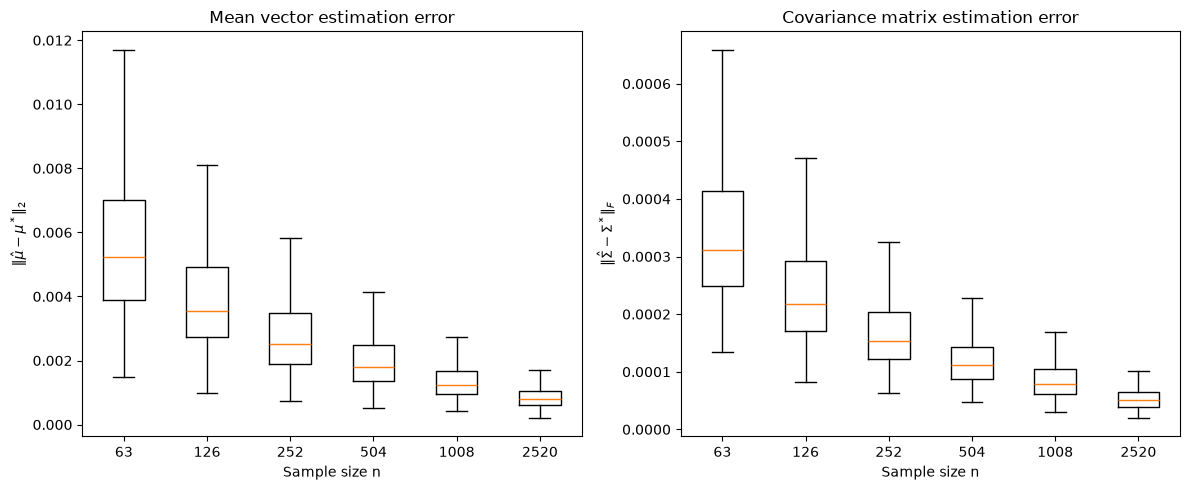

Empirical convergence rate: mu error ~ n^-0.510, Sigma error ~ n^-0.502


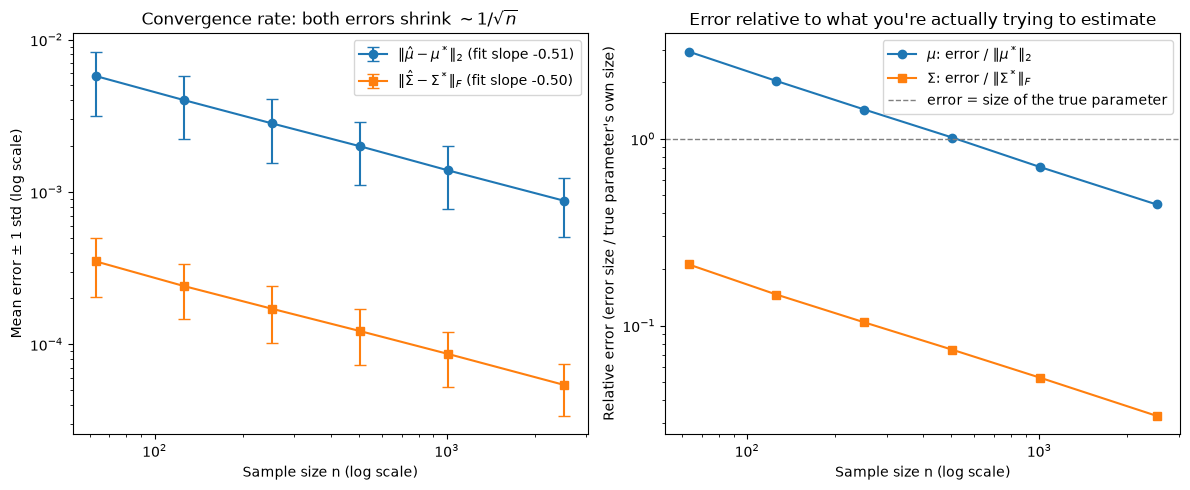

,mu_mean,mu_std,sigma_mean,sigma_std,mu_rel_error,sigma_rel_error
n,,,,,,
63,0.005761,0.002589,0.000350,0.000146,2.927894,0.212634
126,0.004008,0.001776,0.000241,0.000095,2.037041,0.146555
252,0.002819,0.001260,0.000171,0.000069,1.432643,0.104006
504,0.001996,0.000886,0.000122,0.000049,1.014263,0.074248
1008,0.001387,0.000616,0.000086,0.000034,0.704859,0.052560
2520,0.000875,0.000368,0.000054,0.000020,0.444815,0.032883


In [14]:
mu_star = returns.mean()
Sigma_star = returns.cov()

N_GRID = [63, 126, 252, 504, 1008, 2520]
N_REPS = 1000

mu_errors = {n: [] for n in N_GRID}
Sigma_errors = {n: [] for n in N_GRID}

mu_star_vec = mu_star.values
Sigma_star_mat = Sigma_star.values

for n in N_GRID:
    for _ in range(N_REPS):
        sample = np.random.multivariate_normal(mu_star_vec, Sigma_star_mat, size=n)
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        mu_errors[n].append(np.linalg.norm(mu_hat - mu_star_vec))
        Sigma_errors[n].append(np.linalg.norm(Sigma_hat - Sigma_star_mat, ord="fro"))

mu_error_df = pd.DataFrame(mu_errors)
Sigma_error_df = pd.DataFrame(Sigma_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([mu_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[0].set_xlabel("Sample size n")
axes[0].set_ylabel(r"$\|\hat{\mu} - \mu^*\|_2$")
axes[0].set_title("Mean vector estimation error")

axes[1].boxplot([Sigma_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[1].set_xlabel("Sample size n")
axes[1].set_ylabel(r"$\|\hat{\Sigma} - \Sigma^*\|_F$")
axes[1].set_title("Covariance matrix estimation error")
plt.tight_layout()
plt.show()

# --- convergence rate + relative-error summary ---
summary_df = pd.DataFrame({
    "n": N_GRID,
    "mu_mean": [mu_error_df[n].mean() for n in N_GRID],
    "mu_std": [mu_error_df[n].std() for n in N_GRID],
    "sigma_mean": [Sigma_error_df[n].mean() for n in N_GRID],
    "sigma_std": [Sigma_error_df[n].std() for n in N_GRID],
}).set_index("n")

mu_star_norm = np.linalg.norm(mu_star_vec)
Sigma_star_norm = np.linalg.norm(Sigma_star_mat, ord="fro")
summary_df["mu_rel_error"] = summary_df["mu_mean"] / mu_star_norm
summary_df["sigma_rel_error"] = summary_df["sigma_mean"] / Sigma_star_norm

log_n = np.log(N_GRID)
mu_slope, _ = np.polyfit(log_n, np.log(summary_df["mu_mean"]), 1)
sigma_slope, _ = np.polyfit(log_n, np.log(summary_df["sigma_mean"]), 1)
print(f"Empirical convergence rate: mu error ~ n^{mu_slope:.3f}, Sigma error ~ n^{sigma_slope:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(N_GRID, summary_df["mu_mean"], yerr=summary_df["mu_std"], marker="o", capsize=4,
                  label=rf"$\|\hat{{\mu}}-\mu^*\|_2$ (fit slope {mu_slope:.2f})")
axes[0].errorbar(N_GRID, summary_df["sigma_mean"], yerr=summary_df["sigma_std"], marker="s", capsize=4,
                  label=rf"$\|\hat{{\Sigma}}-\Sigma^*\|_F$ (fit slope {sigma_slope:.2f})")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Sample size n (log scale)")
axes[0].set_ylabel("Mean error ± 1 std (log scale)")
axes[0].set_title(r"Convergence rate: both errors shrink $\sim 1/\sqrt{n}$")
axes[0].legend()

axes[1].plot(N_GRID, summary_df["mu_rel_error"], marker="o", label=r"$\mu$: error / $\|\mu^*\|_2$")
axes[1].plot(N_GRID, summary_df["sigma_rel_error"], marker="s", label=r"$\Sigma$: error / $\|\Sigma^*\|_F$")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="error = size of the true parameter")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Sample size n (log scale)")
axes[1].set_ylabel("Relative error (error size / true parameter's own size)")
axes[1].set_title("Error relative to what you're actually trying to estimate")
axes[1].legend()
plt.tight_layout()
plt.show()

summary_df

The boxplots show raw error ($\ell_2$ for $\mu$, Frobenius for $\Sigma$) across 1000 replicates per $n$. The error-bar plot shows the same means with std bars on a log-log scale, plus a fitted slope for the convergence rate. The relative-error plot divides each error by the size of the true parameter, which is what actually determines whether an estimate is usable.

**Convergence rate.** Both errors shrink at almost the same rate: slope $-0.50$ for $\mu$ and $-0.50$ for $\Sigma$ (seed = 1), matching the standard $1/\sqrt{n}$ rate for sample averages. So the difference between them below comes from signal size, not speed.

**$\mu$.** Relative error stays above 1 (error bigger than $\mu^*$ itself) through $n=504$, and only drops below 1 at $n=1008$ (0.72). Even at $n=2520$ (10 years of data) it's still around 0.45. $\mu$ is hard to pin down at any realistic sample size, which is part of why 2.2 uses CAPM instead of the plug-in sample mean.

**$\Sigma$.** Relative error is about 10% at $n=252$, 5% at $n=1008$, and 3% at $n=2520$. Around $n=1008$ is a reasonable point to treat $\hat\Sigma$ as usable.

### Section 2.2 - Model Uncertainty on Real Data

CAPM per-asset alpha / beta / idiosyncratic variance:


,alpha,beta,resid_var
XLC,-0.000098,0.986155,0.000052
XLY,-0.000203,1.112128,0.000046
XLP,0.000072,0.525971,0.000057
XLE,0.000030,0.944929,0.000269
XLF,-0.000092,1.006225,0.000066
XLV,0.000040,0.687451,0.000052
XLI,-0.000030,0.973292,0.000042
XLB,-0.000135,0.944548,0.000061
XLRE,-0.000113,0.807759,0.000093
XLK,0.000170,1.287975,0.000043



Mean vector comparison:


,sample (annualized %),CAPM (annualized %),abs diff
XLF,13.627378,13.627378,1.776357e-14
XLV,11.901987,11.901987,1.243450e-14
XLRE,9.956824,9.956824,1.243450e-14
XLY,12.508134,12.508134,7.105427e-15
XLB,11.575570,11.575570,7.105427e-15
XLI,14.669414,14.669414,5.329071e-15
XLC,13.165491,13.165491,1.776357e-15
XLP,10.145684,10.145684,0.000000e+00
XLE,15.746985,15.746985,0.000000e+00
XLK,24.694812,24.694812,0.000000e+00


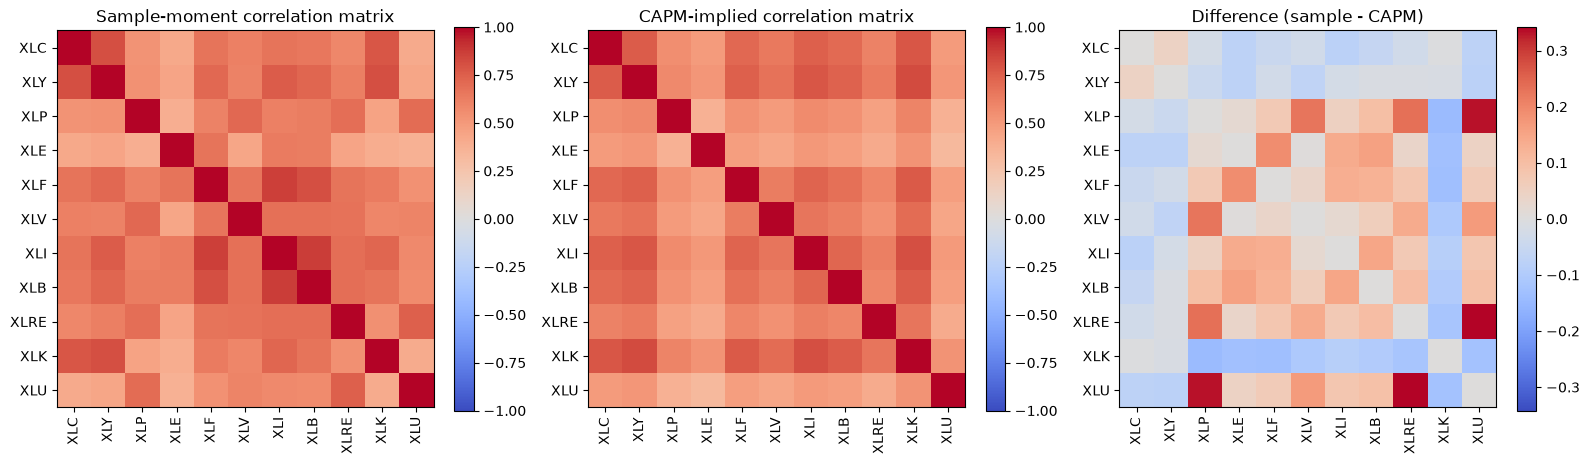


Largest |sample corr - CAPM corr| off-diagonal pairs:


XLRE  XLU    0.341871
XLP   XLU    0.332487
XLRE  XLP    0.234403
XLP   XLV    0.225060
XLF   XLE    0.191589
XLV   XLU    0.165955
XLB   XLE    0.155762
XLI   XLB    0.147915
XLP   XLK   -0.144195
XLRE  XLV    0.138307
Name: corr diff (sample - CAPM), dtype: float64

In [16]:
# --- Method 1: sample moments (just the 11 sector ETFs; SPY excluded since it's the CAPM factor, not a target) ---
mu_sample = returns[TICKERS].mean()
Sigma_sample = returns[TICKERS].cov()
Corr_sample = returns[TICKERS].corr()

# --- Method 2: single-factor CAPM via matrix multiplication (module 2) ---
X = np.column_stack([np.ones(len(returns)), returns[MARKET].values])  # (n, 2): [1, r_SPY]
Y = returns[TICKERS].values                                            # (n, 11)

B_hat = np.linalg.lstsq(X, Y, rcond=None)[0]   # (2, 11): row 0 = alpha_i, row 1 = beta_i
alpha_hat, beta_hat = B_hat[0], B_hat[1]

resids = Y - X @ B_hat
resid_var = resids.var(axis=0, ddof=1)          # idiosyncratic variance per asset (CAPM assumes these are uncorrelated across assets)

r_mkt_mean = returns[MARKET].mean()
r_mkt_var = returns[MARKET].var(ddof=1)

# Law of total expectation: E[mu_i] = alpha_i + beta_i * E[r_market]
mu_capm = pd.Series(alpha_hat + beta_hat * r_mkt_mean, index=TICKERS)

# Law of total covariance: Sigma = beta beta^T * var(r_market) + diag(idiosyncratic variances)
Sigma_capm = pd.DataFrame(
    np.outer(beta_hat, beta_hat) * r_mkt_var + np.diag(resid_var),
    index=TICKERS, columns=TICKERS,
)
Corr_capm = Sigma_capm / np.sqrt(np.outer(np.diag(Sigma_capm), np.diag(Sigma_capm)))

capm_params = pd.DataFrame({"alpha": alpha_hat, "beta": beta_hat, "resid_var": resid_var}, index=TICKERS)
print("CAPM per-asset alpha / beta / idiosyncratic variance:")
display(capm_params)

# --- Side-by-side mean vectors (annualized, x252, for readability) ---
mu_compare = pd.DataFrame({
    "sample (annualized %)": mu_sample * 252 * 100,
    "CAPM (annualized %)": mu_capm * 252 * 100,
})
mu_compare["abs diff"] = (mu_compare["sample (annualized %)"] - mu_compare["CAPM (annualized %)"]).abs()
print("\nMean vector comparison:")
display(mu_compare.sort_values("abs diff", ascending=False))

# --- Covariance / correlation comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(Corr_sample, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks(range(len(TICKERS))); axes[0].set_xticklabels(TICKERS, rotation=90)
axes[0].set_yticks(range(len(TICKERS))); axes[0].set_yticklabels(TICKERS)
axes[0].set_title("Sample-moment correlation matrix")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Corr_capm, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_xticks(range(len(TICKERS))); axes[1].set_xticklabels(TICKERS, rotation=90)
axes[1].set_yticks(range(len(TICKERS))); axes[1].set_yticklabels(TICKERS)
axes[1].set_title("CAPM-implied correlation matrix")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

corr_diff = Corr_sample - Corr_capm
lim = np.abs(corr_diff.values).max()
im2 = axes[2].imshow(corr_diff, vmin=-lim, vmax=lim, cmap="coolwarm")
axes[2].set_xticks(range(len(TICKERS))); axes[2].set_xticklabels(TICKERS, rotation=90)
axes[2].set_yticks(range(len(TICKERS))); axes[2].set_yticklabels(TICKERS)
axes[2].set_title("Difference (sample - CAPM)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# --- Which off-diagonal pairs differ the most? ---
diff_stacked = corr_diff.where(~np.eye(len(TICKERS), dtype=bool)).stack()
top_diff_pairs = diff_stacked.abs().sort_values(ascending=False).drop_duplicates().head(10)
print("\nLargest |sample corr - CAPM corr| off-diagonal pairs:")
display(diff_stacked.loc[top_diff_pairs.index].rename("corr diff (sample - CAPM)"))

**Mean vector.** Sample and CAPM means match almost exactly (differences around $10^{-14}$, floating-point noise). This is expected: OLS with an intercept always fits through the average, so $\hat\alpha_i + \hat\beta_i\bar r_{\text{SPY}}$ reduces to the sample mean itself. CAPM's effect here is entirely in $\Sigma$, not $\mu$.

**Why correlation instead of covariance.** Correlation is on a fixed $[-1,1]$ scale, so differences between pairs are directly comparable regardless of each asset's own volatility.

**Covariance / correlation.** The two methods disagree a lot. The ten largest correlation gaps between the sample and CAPM matrices range from about 0.14 to 0.34, which is large relative to the full possible range of 2.

**Sensitivity.** Since $\mathbf{w}^*$ depends on $\hat\Sigma^{-1}$, a correlation gap of this size can noticeably change the optimal weights. The choice of estimation method matters here, not just sampling noise within one method.

**Where the gap comes from.** Nine of the ten largest gaps have sample correlation higher than CAPM's -- those sector pairs move together more than a shared SPY beta explains. One pair (XLP-XLK) goes the other way, with CAPM implying a higher correlation than what actually happened.

### Section 2.3 - Bootstrap and Rolling Window

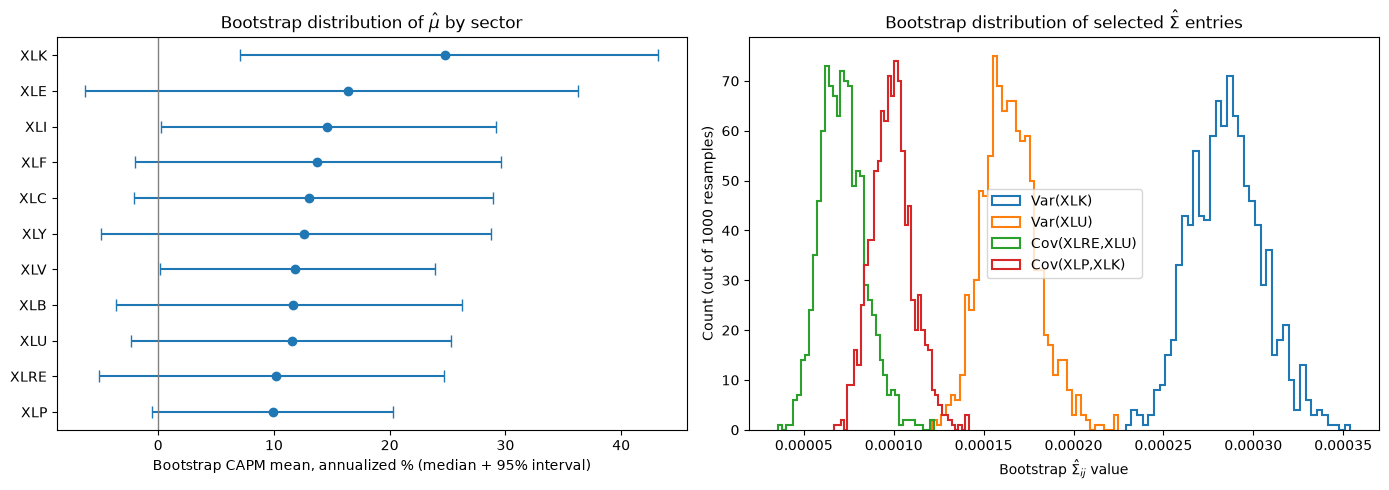

In [27]:
def fit_capm(ret_df):
    """Single-factor CAPM fit (as in 2.2): returns (mu_hat, Sigma_hat) as plain numpy arrays."""
    X = np.column_stack([np.ones(len(ret_df)), ret_df[MARKET].values])
    Y = ret_df[TICKERS].values
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    alpha, beta = B[0], B[1]
    resid_var = (Y - X @ B).var(axis=0, ddof=1)
    r_mkt_mean = ret_df[MARKET].mean()
    r_mkt_var = ret_df[MARKET].var(ddof=1)
    mu = alpha + beta * r_mkt_mean
    Sigma = np.outer(beta, beta) * r_mkt_var + np.diag(resid_var)
    return mu, Sigma


# --- Bootstrap: resample days with replacement, refit CAPM each time ---
N_BOOT = 1000
n_obs = len(returns)
rng = np.random.default_rng(RNG_SEED)

boot_mu = np.zeros((N_BOOT, len(TICKERS)))
boot_Sigma = np.zeros((N_BOOT, len(TICKERS), len(TICKERS)))

for b in range(N_BOOT):
    idx = rng.integers(0, n_obs, size=n_obs)
    resampled = returns.iloc[idx]
    boot_mu[b], boot_Sigma[b] = fit_capm(resampled)

# Forest plot: bootstrap mean (annualized %) and 95% percentile interval per sector
mu_annual = boot_mu * 252 * 100
mu_median = np.median(mu_annual, axis=0)
mu_lo = np.percentile(mu_annual, 2.5, axis=0)
mu_hi = np.percentile(mu_annual, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = np.argsort(mu_median)
axes[0].errorbar(mu_median[order], np.arange(len(TICKERS)),
                  xerr=[mu_median[order] - mu_lo[order], mu_hi[order] - mu_median[order]],
                  fmt="o", capsize=4)
axes[0].set_yticks(np.arange(len(TICKERS)))
axes[0].set_yticklabels(np.array(TICKERS)[order])
axes[0].axvline(0, color="gray", linewidth=1)
axes[0].set_xlabel("Bootstrap CAPM mean, annualized % (median + 95% interval)")
axes[0].set_title("Bootstrap distribution of $\\hat{\\mu}$ by sector")

# Distribution of a few Sigma_hat entries: two variances, two covariance pairs
tickers_idx = {t: i for i, t in enumerate(TICKERS)}
pairs_to_show = [("XLK", "XLK"), ("XLU", "XLU"), ("XLRE", "XLU"), ("XLP", "XLK")]
for (a, c) in pairs_to_show:
    ia, ic = tickers_idx[a], tickers_idx[c]
    label = f"Var({a})" if a == c else f"Cov({a},{c})"
    axes[1].hist(boot_Sigma[:, ia, ic], bins=40, histtype="step", linewidth=1.5, label=label)
axes[1].set_xlabel("Bootstrap $\\hat{\\Sigma}_{ij}$ value")
axes[1].set_ylabel("Count (out of 1000 resamples)")
axes[1].set_title("Bootstrap distribution of selected $\\hat{\\Sigma}$ entries")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.dates as mdates

# --- Rolling window: refit CAPM on each trailing 252-day window, in time order ---
WINDOW = 252
roll_dates = returns.index[WINDOW - 1:]
n_windows = len(roll_dates)

roll_mu = np.zeros((n_windows, len(TICKERS)))
roll_vol = np.zeros((n_windows, len(TICKERS)))  # annualized volatility (sqrt of diag Sigma) -- per-asset only
roll_mu_norm = np.zeros(n_windows)              # ||mu_hat||_2, daily units -- mu_hat as a whole vector
roll_Sigma_fro = np.zeros(n_windows)            # ||Sigma_hat||_F, daily units -- Sigma_hat as a whole matrix

pairs_to_track = [("XLRE", "XLU"), ("XLP", "XLU"), ("XLK", "XLY")]
roll_corr = {pair: np.zeros(n_windows) for pair in pairs_to_track}

for i in range(n_windows):
    window_df = returns.iloc[i:i + WINDOW]
    mu_t, Sigma_t = fit_capm(window_df)
    roll_mu[i] = mu_t
    roll_vol[i] = np.sqrt(np.diag(Sigma_t)) * np.sqrt(252)
    roll_mu_norm[i] = np.linalg.norm(mu_t)
    roll_Sigma_fro[i] = np.linalg.norm(Sigma_t, ord="fro")

    for (a, c) in pairs_to_track:
        ia, ic = tickers_idx[a], tickers_idx[c]
        roll_corr[(a, c)][i] = Sigma_t[ia, ic] / np.sqrt(Sigma_t[ia, ia] * Sigma_t[ic, ic])

roll_mu_annual = roll_mu * 252 * 100
roll_vol_pct = roll_vol * 100
date_nums = mdates.date2num(roll_dates)
covid_start, covid_end = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")


def format_date_axis(ax):
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 4, 7, 10]))
    ax.set_xlabel("Date (window is the trailing 252 trading days ending on this date)")


# --- Heatmaps: mu and volatility, per sector (both have colorbars, so their axes compress the same way) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

im0 = axes[0].imshow(roll_mu_annual.T, aspect="auto", cmap="coolwarm",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[0].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[0].set_yticklabels(TICKERS)
axes[0].set_title(r"Rolling 252-day CAPM $\hat{\mu}$, annualized % (heatmap over time)")
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(roll_vol_pct.T, aspect="auto", cmap="viridis",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[1].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[1].set_yticklabels(TICKERS)
axes[1].set_title(r"Rolling 252-day annualized volatility % (heatmap over time, per sector)")
plt.colorbar(im1, ax=axes[1], fraction=0.03)

for ax in axes:
    format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- Correlation: its own figure, no colorbar, so its axis isn't compressed relative to the heatmaps ---
fig, ax = plt.subplots(figsize=(12, 4))
for pair, series in roll_corr.items():
    ax.plot(roll_dates, series, label=f"{pair[0]}-{pair[1]}")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("Rolling correlation")
ax.set_title("Rolling correlation for selected sector pairs")
ax.legend()
format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- The actual comparison we care about: mu_hat as a whole vector vs Sigma_hat as a whole matrix ---
# Per-sector volatility above only looks at the diagonal of Sigma_hat. The Frobenius norm folds in
# every variance AND covariance entry, which is what the optimizer (Sigma_hat^-1 mu_hat) actually
# uses. ||mu_hat|| is in return units and ||Sigma_hat||_F is in return-units-squared, so the two
# aren't comparable in raw form -- standardizing each to its own z-score removes that mismatch and
# is unaffected by any constant scaling (e.g. annualizing), so we just use daily units directly.
mu_norm_s = pd.Series(roll_mu_norm, index=roll_dates)
sigma_fro_s = pd.Series(roll_Sigma_fro, index=roll_dates)
mu_norm_z = (mu_norm_s - mu_norm_s.mean()) / mu_norm_s.std()
sigma_fro_z = (sigma_fro_s - sigma_fro_s.mean()) / sigma_fro_s.std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_dates, mu_norm_z, label=r"$\|\hat{\mu}\|_2$, standardized")
ax.plot(roll_dates, sigma_fro_z, label=r"$\|\hat{\Sigma}\|_F$, standardized")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("z-score")
ax.set_title(r"$\|\hat{\mu}\|_2$ vs. $\|\hat{\Sigma}\|_F$, standardized to the same scale")
ax.legend()
format_date_axis(ax)
plt.tight_layout()
plt.show()

print("Average |z-score| over time -- ||mu_hat||:", round(mu_norm_z.abs().mean(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().mean(), 2))
print("Largest |z-score| reached -- ||mu_hat||:", round(mu_norm_z.abs().max(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().max(), 2))
print("Correlation between the two raw series over time:", round(mu_norm_s.corr(sigma_fro_s), 3))

**Bootstrap.** $\hat\mu$ is volatile: 8 of 11 sectors have a 95% interval that includes zero. $\hat\Sigma$ is much more tightly distributed around its point estimate. This matches 2.1: $\mu$ is the harder parameter to pin down.

**Rolling window.** $\hat\mu$ is noisy over time and flips sign often in the top heatmap (blue to red). The per-sector volatility heatmap only looks at the diagonal of $\hat\Sigma$, so it's not the full picture -- the optimizer uses all of $\hat\Sigma$, variances and covariances together. Using $\|\hat\Sigma\|_F$ (the whole matrix) instead of just volatility gives a fair comparison to $\|\hat\mu\|_2$ (the whole mean vector), both standardized to the same scale: average variability is close (0.72 for $\mu$, also 0.72 for $\Sigma$), but $\mu$ reaches a much larger extreme (max z of 5.6 vs. 2.7 for $\Sigma$), and the two series are barely correlated with each other (0.04) -- they don't necessarily spike at the same time.

Overall $\Sigma$ is still the steadier estimate: it stays in a more predictable range and doesn't flip sign, while $\mu$ swings further and occasionally moves to an extreme with no clear counterpart in $\Sigma$.

**Regimes.** Crashes raise correlation and volatility across sectors -- COVID (Feb-Apr 2020) is the clearest example, and similar tariff-driven selloffs do the same. Because the window is 252 trading days, one crash keeps distorting the rolling estimate for about a year afterward, which is why volatility and correlation stay elevated well past the event itself and only fall once the crash days roll out of the window. $\|\hat\Sigma\|_F$ peaks in a window dated January 2021, for the same reason.

There's also a separate low-$\mu$ period in the middle of the sample, from mid-2022 to early 2023, bottoming around October 2022 -- distinct from the COVID trough and consistent with the 2022 rate-hike selloff.

### Section 2.4 - Dimension vs. Sample Size

In [ ]:
# --- Ground truth mu*(k), Sigma*(k) for arbitrary k ---
# k <= 12: subset of the real full-sample estimates from 2.1 (mu_star, Sigma_star -- 12 columns,
#          TICKERS + SPY, so we have exactly 12 real assets to draw from).
# k > 12:  no more real assets exist, so we build a synthetic k-asset universe using the same
#          one-factor structure as the 2.2 CAPM fit: Sigma*(k) = diag(D) + beta beta^T * sigma_m^2.
#          beta and D are drawn from distributions fit to the 11 real CAPM betas / residual
#          variances from 2.2, so the synthetic universe still reflects real, estimated market
#          behavior rather than made-up numbers.

beta_fit_mean, beta_fit_std = beta_hat.mean(), beta_hat.std(ddof=1)
log_resid_var = np.log(resid_var)
logvar_fit_mean, logvar_fit_std = log_resid_var.mean(), log_resid_var.std(ddof=1)  # log-normal: residual variances must stay positive, and the real 11 are right-skewed

K_GRID = [5, 12, 50, 150, 252, 500, 1000]
rng24 = np.random.default_rng(RNG_SEED)


def ground_truth(k):
    """Return (mu_star_k, Sigma_star_k), the (synthetic, for k>12) true parameters for a k-asset universe."""
    if k <= 12:
        mu_k = mu_star_vec[:k]
        Sigma_k = Sigma_star_mat[:k, :k]
    else:
        beta_k = rng24.normal(beta_fit_mean, beta_fit_std, size=k)
        D_k = np.exp(rng24.normal(logvar_fit_mean, logvar_fit_std, size=k))
        Sigma_k = np.outer(beta_k, beta_k) * r_mkt_var + np.diag(D_k)
        mu_k = beta_k * r_mkt_mean  # zero synthetic alpha: no built-in mispricing for the made-up assets
    return mu_k, Sigma_k


# --- Sanity checks: does the construction actually look right? ---
print(f"Real beta: mean={beta_fit_mean:.3f}, std={beta_fit_std:.3f}")
print(f"Real idiosyncratic variance: mean={resid_var.mean():.6f}, range=[{resid_var.min():.6f}, {resid_var.max():.6f}]")

# k <= 12 should reproduce the 2.1 real estimates exactly
mu_12, Sigma_12 = ground_truth(12)
print("k=12 matches 2.1 real estimates exactly:",
      np.allclose(mu_12, mu_star_vec) and np.allclose(Sigma_12, Sigma_star_mat))

# For a large synthetic k, compare the drawn beta/D distribution to the real 11 values
rng_plot = np.random.default_rng(RNG_SEED)
beta_400 = rng_plot.normal(beta_fit_mean, beta_fit_std, size=400)
D_400 = np.exp(rng_plot.normal(logvar_fit_mean, logvar_fit_std, size=400))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(beta_400, bins=30, density=True, alpha=0.6, label="synthetic beta (k=400 draw)")
axes[0].scatter(beta_hat, np.zeros_like(beta_hat), color="red", zorder=5, label="real 11 betas")
axes[0].set_title("Synthetic beta draws vs. real sector betas")
axes[0].set_xlabel(r"$\beta$")
axes[0].legend()

axes[1].hist(D_400, bins=30, density=True, alpha=0.6, label="synthetic idiosyncratic var (k=400 draw)")
axes[1].scatter(resid_var, np.zeros_like(resid_var), color="red", zorder=5, label="real 11 residual variances")
axes[1].set_title("Synthetic idiosyncratic variance vs. real values")
axes[1].set_xlabel(r"idiosyncratic variance")
axes[1].legend()

plt.tight_layout()
plt.show()

**How $\boldsymbol\mu^*(k)$ and $\boldsymbol\Sigma^*(k)$ are built.** For $k \le 12$ we just reuse the real full-sample estimates from 2.1 ($\mu^*$, $\Sigma^*$ over all 12 tickers, sector ETFs plus SPY) and take the first $k$ columns/rows. For $k>12$ there's no real 13th asset, so we build a synthetic one instead, using the same one-factor structure as the 2.2 CAPM fit: $\Sigma^*(k) = \boldsymbol\beta\boldsymbol\beta^\top\sigma_m^2 + \mathbf{D}$. $\sigma_m^2$ is the real SPY variance from 2.2. $\boldsymbol\beta$ is drawn from a normal distribution fit to the 11 real CAPM betas (mean 0.898, std 0.224). $\mathbf{D}$'s entries are drawn from a log-normal fit to the 11 real residual variances -- log-normal because variances have to stay positive and the real 11 are right-skewed (mostly 4-11e-5, with XLE at 2.7e-4). $\mu^*(k)$ for the synthetic assets is $\boldsymbol\beta \cdot \bar r_{\text{SPY}}$, i.e. zero alpha -- we don't have a real alpha to draw from for a made-up asset, and zero alpha is the standard "fairly priced" CAPM assumption anyway.

In [ ]:
# --- Simulate at each k: draw N_REPS_24 samples of size n=252 from N(mu*(k), Sigma*(k)),
#     compute Sigma_hat each time, and track condition number, smallest eigenvalue, and ||w*|| ---
N_REPS_24 = 200
N_SIM = 252          # sample size fixed for the whole subsection, per the prompt
GAMMA_24 = 5.0        # fixed risk aversion, just so w* has one consistent scale across k

results_24 = {}
for k in K_GRID:
    mu_k, Sigma_k = ground_truth(k)
    L = np.linalg.cholesky(Sigma_k)  # fixed per k; reused so we don't refactor Sigma_k every replicate

    cond_list, mineig_list, wnorm_list, gl_list = [], [], [], []
    for _ in range(N_REPS_24):
        Z = np.random.standard_normal((N_SIM, k))
        sample = mu_k + Z @ L.T
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        eigvals = np.linalg.eigvalsh(Sigma_hat)
        min_eig = eigvals.min()
        cond_list.append(eigvals.max() / max(min_eig, 1e-14))
        mineig_list.append(min_eig)

        # w* = (1/gamma) Sigma_hat^-1 mu_hat -- solved directly (no regularization), so it shows
        # exactly what a naive implementation would do with a near-singular or singular Sigma_hat
        w = np.linalg.solve(Sigma_hat, mu_hat) / GAMMA_24
        wnorm_list.append(np.linalg.norm(w))
        gl_list.append(np.abs(w).sum())

    results_24[k] = dict(cond=np.array(cond_list), min_eig=np.array(mineig_list),
                          w_norm=np.array(wnorm_list), gross_lev=np.array(gl_list))

# median + interquartile band per k, for plotting
summary_24 = pd.DataFrame({
    "k": K_GRID,
    "cond_med": [np.median(results_24[k]["cond"]) for k in K_GRID],
    "cond_lo": [np.percentile(results_24[k]["cond"], 25) for k in K_GRID],
    "cond_hi": [np.percentile(results_24[k]["cond"], 75) for k in K_GRID],
    "mineig_med": [np.median(results_24[k]["min_eig"]) for k in K_GRID],
    "mineig_frac_nonpos": [(results_24[k]["min_eig"] <= 1e-10).mean() for k in K_GRID],
    "wnorm_med": [np.median(results_24[k]["w_norm"]) for k in K_GRID],
    "wnorm_lo": [np.percentile(results_24[k]["w_norm"], 25) for k in K_GRID],
    "wnorm_hi": [np.percentile(results_24[k]["w_norm"], 75) for k in K_GRID],
    "grosslev_med": [np.median(results_24[k]["gross_lev"]) for k in K_GRID],
}).set_index("k")
display(summary_24)

# categorical x positions (evenly spaced), labeled with the actual k values -- K_GRID isn't
# evenly spaced (5 to 1000), so a true linear or log axis would squeeze the small-k points together
x_pos = np.arange(len(K_GRID))
k_idx = K_GRID.index(N_SIM)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(x_pos, summary_24["cond_med"], marker="o")
axes[0].fill_between(x_pos, summary_24["cond_lo"], summary_24["cond_hi"], alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("k")
axes[0].set_ylabel(r"condition number of $\hat{\Sigma}$ (log scale)")
axes[0].set_title("Condition number vs. k")
axes[0].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[0].legend()

# smallest eigenvalue: plot |value|, marker color shows whether it's still positive (valid) or
# has gone numerically zero/negative (Sigma_hat is no longer really invertible)
colors = ["tab:blue" if summary_24.loc[k, "mineig_frac_nonpos"] < 0.5 else "tab:red" for k in K_GRID]
axes[1].plot(x_pos, summary_24["mineig_med"].abs(), color="black", linewidth=1, zorder=1)
axes[1].scatter(x_pos, summary_24["mineig_med"].abs(), c=colors, zorder=2, s=60)
axes[1].set_yscale("log")
axes[1].set_xlabel("k")
axes[1].set_ylabel(r"$|$smallest eigenvalue of $\hat{\Sigma}|$ (log scale)")
axes[1].set_title("Smallest eigenvalue vs. k\n(blue = still positive, red = <= 0, i.e. singular)")
axes[1].axvline(k_idx, color="gray", linestyle="--")

axes[2].plot(x_pos, summary_24["wnorm_med"], marker="o", label=r"median $\|\mathbf{w}^*\|_2$")
axes[2].fill_between(x_pos, summary_24["wnorm_lo"], summary_24["wnorm_hi"], alpha=0.2)
axes[2].set_yscale("log")
axes[2].set_xlabel("k")
axes[2].set_ylabel(r"$\|\mathbf{w}^*\|_2$ (log scale)")
axes[2].set_title(r"Unconstrained $\|\mathbf{w}^*\|_2$ vs. k")
axes[2].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(K_GRID)

plt.tight_layout()
plt.show()

All three quantities are flat and modest while $k < n$, then jump by many orders of magnitude right at $k=n=252$: condition number goes from about 5,857 at $k=150$ to $3.3\times10^{12}$ at $k=252$; the smallest eigenvalue flips from a tiny positive number ($3\times10^{-6}$) to a tiny negative one ($-2.4\times10^{-21}$); and $\|\mathbf{w}^*\|_2$ goes from about 79 to $1.3\times10^{15}$. By $k=500$ and $k=1000$, every single replicate has a non-positive smallest eigenvalue.

The jump happens exactly at $k=n$, not somewhere after it, because estimating the sample mean uses up one degree of freedom -- a sample covariance from $n$ rows can have rank at most $n-1$. So once $k \ge n$, $\hat\Sigma$ is mathematically guaranteed to be singular, not just poorly estimated.

This connects directly to $\mathbf{w}^* \propto \hat{\Sigma}^{-1}\hat{\mu}$: inverting a matrix means dividing by its eigenvalues, so a matrix with a near-zero eigenvalue produces a near-infinite result in that direction once inverted. `np.linalg.solve` doesn't error out here -- floating-point rounding keeps the determinant technically nonzero -- so it just silently returns an enormous, meaningless weight vector instead of failing loudly. That's arguably worse than a crash.

The important part is that this is entirely an estimation problem, not a property of the market. 2.4a already confirmed $\Sigma^*(k)$ itself -- the true parameter -- has a strictly positive smallest eigenvalue at every $k$ we tested, including $k=1000$. $n=252$ days simply isn't enough data to pin down a $1000\times1000$ covariance matrix; the true structure is fine, the estimate of it is not. This is why Section 3.5's constrained weights, and shrinkage estimators like Ledoit-Wolf in practice, exist: rather than inverting $\hat\Sigma$ as-is, they push it toward something better-conditioned before inverting, trading a bit of bias for a covariance matrix that's actually safe to divide by.

## Section 3 - How Uncertainty in Parameters Propagates to Weights

### Section 3.1 - Sensitivity to Gamma

### Section 3.2 - Sensitivity to Mu

### Section 3.3 - Sensitivity to Correlations

### Section 3.4 - Sensitivity to Volatility

### Section 3.5 - A Dose of Realism: Constrained Weights

## Section 4 - The Effect of Rebalancing and Trading Costs

### Section 4.1 - Frictionless Rebalancing

### Section 4.2 - Introducing Transaction Costs

## Section 5 - Full Backtester

### Section 5.1 - The Loop

### Section 5.2 - Performance Report: The Tearsheet

### Section 5.3 - Interpretation

_TODO: write interpretation paragraphs here._

## Section 6 - Bonus: Push the Strategy Further (Optional)